**Importing the Dataset**

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("/content/student-mat.csv", sep=";")

**Dataset Checks and Preprocesing**

In [40]:
print("Dataset Shape:", df.shape)
df.head(5)
df.info()
df.describe()
print(df.isnull().sum())
print("Duplicate Rows:", df.duplicated().sum())

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])


df.info()

Dataset Shape: (395, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null 

**Input Features and Target Variable Selection**

In [41]:
X = df.drop("G3", axis=1)
y = df["G3"]

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)



Features:
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2'],
      dtype='object')

Target:
G3


**Train-Test Split**

In [42]:
scaler = StandardScaler()
X = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (316, 32)
Testing Samples: (79, 32)


**Implementing Linear Regression using Gradient Descent**

In [43]:
def gradient_descent(X, y, lr=0.01, iterations=1000):

    m = len(y)

    weights = np.zeros(X.shape[1])
    bias = 0

    losses = []

    for i in range(iterations):

        y_pred = np.dot(X, weights) + bias

        dw = (1/m) * np.dot(X.T, (y_pred - y))
        db = (1/m) * np.sum(y_pred - y)

        weights = weights - lr * dw
        bias = bias - lr * db

        loss = (1/(2*m)) * np.sum((y_pred - y)**2)
        losses.append(loss)

    return weights, bias, losses





In [44]:
weights, bias, losses = gradient_descent(
    X_train,
    y_train,
    lr=0.01,
    iterations=1000
)

**Experimenting with different learning rates**

In [45]:
learning_rates = [0.001, 0.01, 0.1]

for lr in learning_rates:

    _, _, loss = gradient_descent(
        X_train,
        y_train,
        lr=lr,
        iterations=1000
    )



**Plot the loss (cost) versus the number of iterations.**

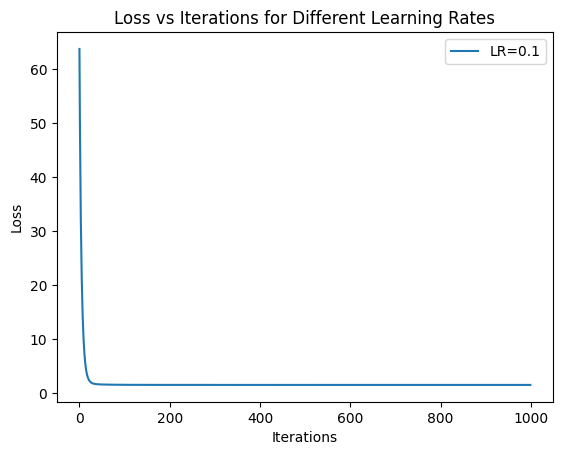

In [46]:
plt.plot(loss, label=f"LR={lr}")
plt.title("Loss vs Iterations for Different Learning Rates")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()



**Plotting Actual vs Predicted values**

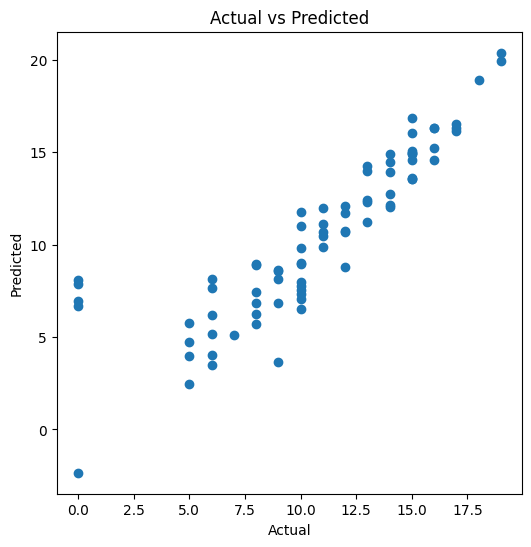

,Actual,Predicted
0,10,6.526641
1,12,11.687729
2,5,2.435461
3,10,7.987886
4,9,8.610367
5,13,12.300731
6,18,18.896732
7,6,7.626467
8,0,6.943973
9,14,12.026977


In [47]:

y_pred = np.dot(X_test, weights) + bias

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()


results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(10)

**Evaluating the trained model**

In [48]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 1.5465442517695527
MSE : 5.09290834757595
RMSE: 2.2567472936897364
R2 Score: 0.7516265980275255


**Interpretation**

**Convergence Behavior:**

1. The loss decreases continuously with each iteration, showing that Gradient Descent successfully minimizes the cost function.
2. A learning rate of 0.001 converges slowly, while 0.01 and 0.1 converge much faster.
3. Among the tested values, 0.1 achieved the fastest stable convergence.

**Prediction Performance:**

1. The model achieved an MAE of 1.55, indicating that predictions differ from the actual grades by about 1.5 marks on average.
2. The RMSE of 2.26 shows relatively low prediction error.
3. The R² score of 0.75 indicates that approximately 75% of the variation in students' final grades is explained by the model, demonstrating good predictive performance.